In [1]:
import pandas as pd

df = pd.read_csv("/content/marketing_campaign_dataset.csv", encoding='latin1')
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [2]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')

In [3]:
df = df.dropna()
df = df.drop_duplicates()

In [9]:
channel = df.groupby('Channel_Used').agg({
    'ROI': 'mean',
    'Conversion_Rate': 'mean',
    'CTR': 'mean',
    'Clicks': 'sum',
    'Impressions': 'sum'
}).reset_index()

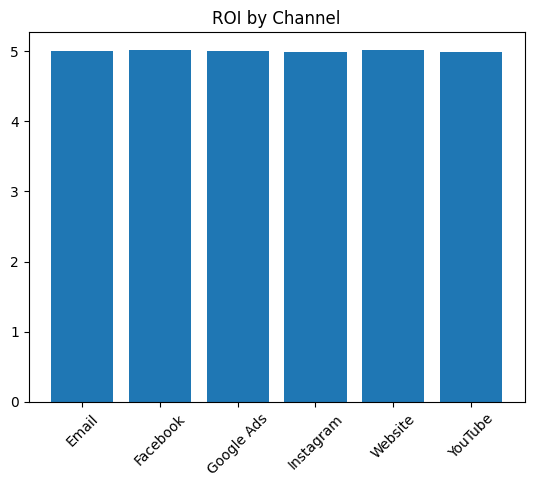

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(channel['Channel_Used'], channel['ROI'])
plt.title("ROI by Channel")
plt.xticks(rotation=45)
plt.show()

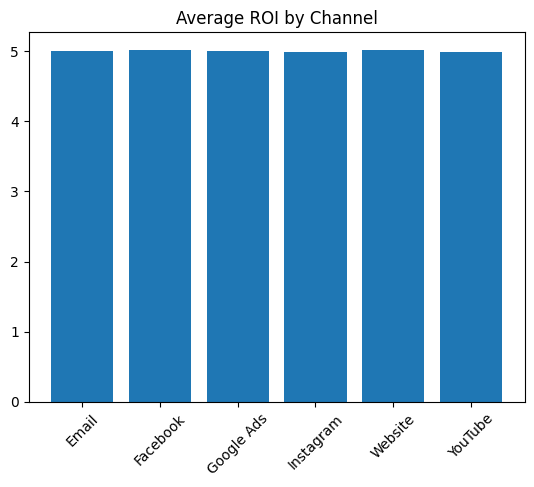

In [11]:
channel = df.groupby('Channel_Used')['ROI'].mean().reset_index()

plt.figure()
plt.bar(channel['Channel_Used'], channel['ROI'])
plt.title("Average ROI by Channel")
plt.xticks(rotation=45)
plt.show()

In [12]:
channel = df.groupby('Channel_Used')['CTR'].mean().reset_index()

In [13]:
df['CTR'] = df['Clicks'] / df['Impressions']

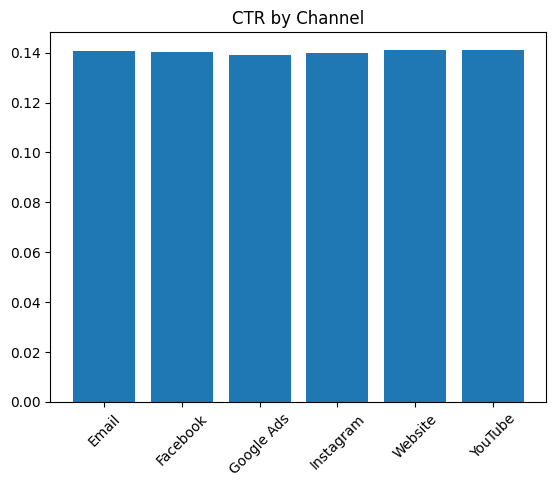

In [14]:
channel_ctr = df.groupby('Channel_Used')['CTR'].mean().reset_index()

import matplotlib.pyplot as plt
plt.figure()
plt.bar(channel_ctr['Channel_Used'], channel_ctr['CTR'])
plt.title("CTR by Channel")
plt.xticks(rotation=45)
plt.show()

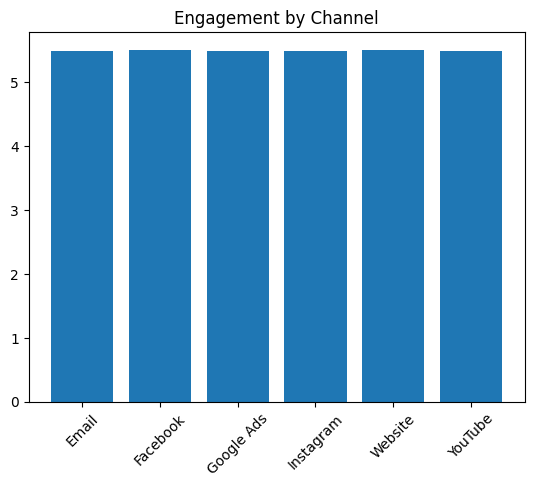

In [15]:
engagement = df.groupby('Channel_Used')['Engagement_Score'].mean().reset_index()

plt.figure()
plt.bar(engagement['Channel_Used'], engagement['Engagement_Score'])
plt.title("Engagement by Channel")
plt.xticks(rotation=45)
plt.show()

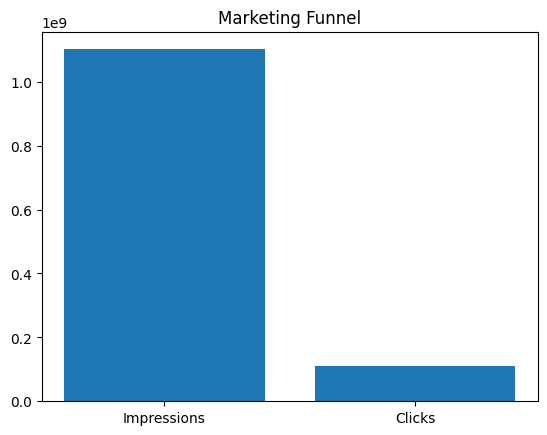

In [16]:
funnel = df[['Impressions','Clicks']].sum()

plt.figure()
plt.bar(funnel.index, funnel.values)
plt.title("Marketing Funnel")
plt.show()